# 【Day 07 實作】上傳 PDF 給 AI，它到底讀到了什麼？

## Goal

[Day 7 文章](./day07.md) 提到：上傳 PDF，不代表模型拿到的內容會與人眼看到的頁面完全相同。這份 notebook 用同一頁 PDF，比較三種讀取視角：

1. **人工標註的評估錨點**：由人閱讀頁面後，記下少量可核對項目。
2. **`pypdf` 文字擷取**：讀取 PDF 文字層。
3. **Groq 視覺模型**：把單頁轉成圖片，再請模型謄寫文字並描述非文字內容。

### 實驗問題

- 表格中的指定數值是否保留？
- 圖片區塊是否被辨認或描述？
- 圖說與頁碼是否一致？
- 不同讀取路徑會出現哪些不同類型的落差？

### 流程

`建立人工錨點 → 顯示原頁 → pypdf 擷取 → 視覺模型讀圖 → 對照證據與限制`

> **實驗定位：**這是探索性、單頁、單模型、單次輸出的教學示範，不是完整的 OCR、PDF 工具或模型準確率評測。

### 資料來源

- PDF：[Day7/2112.10752v2.pdf](./2112.10752v2.pdf)
- 論文：Rombach et al., *High-Resolution Image Synthesis with Latent Diffusion Models*（[arXiv:2112.10752](https://arxiv.org/abs/2112.10752)）
- 示範頁：PDF 第 21 頁，包含 Table 8 與 Figure 16。Figure 16 是 8 欄 × 5 列，共 **40 個面板（8 個 layout + 32 張生成影像）**。


## Setup

請從 repo 根目錄或 `Day7` 目錄啟動 notebook，讓下方相對路徑能找到 PDF。安裝所需套件，並把 `GROQ_API_KEY` 放在專案根目錄的 `.env`：

```text
GROQ_API_KEY=你的金鑰
```

只有 Step 4 會把公開論文的單頁圖片送到 Groq。若改用自己的 PDF，請勿上傳機密、個資或其他不適合交給第三方 API 的內容。

Step 3 與 Step 4 會先顯示完整原始輸出，再執行自動檢查。原始輸出放在可捲動區域，方便逐段觀察，又不會讓頁面變成整面文字牆。Step 4 會在執行時讀取 `.env` 中的金鑰並呼叫 Groq。


In [1]:
%pip install -q pypdf pymupdf groq python-dotenv


Note: you may need to restart the kernel to use updated packages.


In [2]:
import base64
import os
from importlib.metadata import PackageNotFoundError, version

import fitz  # PyMuPDF
import groq
from dotenv import find_dotenv, load_dotenv
from groq import Groq
from IPython.display import Image, Markdown, display
from pypdf import PdfReader

load_dotenv(find_dotenv(usecwd=True))

PACKAGE_DISTRIBUTIONS = {
    "pypdf": "pypdf",
    "PyMuPDF": "PyMuPDF",
    "groq": "groq",
    "python-dotenv": "python-dotenv",
}
PACKAGE_VERSIONS = {}
for package_name, distribution_name in PACKAGE_DISTRIBUTIONS.items():
    try:
        PACKAGE_VERSIONS[package_name] = version(distribution_name)
    except PackageNotFoundError:
        PACKAGE_VERSIONS[package_name] = "not installed"

CANDIDATE_PDF_PATHS = ["2112.10752v2.pdf", "Day7/2112.10752v2.pdf"]
PDF_PATH = next((path for path in CANDIDATE_PDF_PATHS if os.path.exists(path)), None)
if PDF_PATH is None:
    raise FileNotFoundError(f"找不到 PDF，已檢查：{CANDIDATE_PDF_PATHS}")

PAGE_INDEX = 20  # 從 0 開始計算，對應 PDF 第 21 頁
reader = PdfReader(PDF_PATH)
doc = fitz.open(PDF_PATH)
if not (0 <= PAGE_INDEX < len(reader.pages)):
    raise ValueError(
        f"PAGE_INDEX={PAGE_INDEX} 超出範圍，這份 PDF 只有 {len(reader.pages)} 頁。"
    )

print(f"PDF 共 {len(reader.pages)} 頁；示範頁為第 {PAGE_INDEX + 1} 頁。")
print(
    "套件版本："
    + " / ".join(
        f"{package_name} {PACKAGE_VERSIONS[package_name]}"
        for package_name in PACKAGE_DISTRIBUTIONS
    )
)


PDF 共 45 頁；示範頁為第 21 頁。
套件版本：pypdf 5.6.0 / PyMuPDF 1.28.0 / groq 1.6.0 / python-dotenv 1.1.0


## Step 1 — 建立人工標註的評估錨點

先直接閱讀 PDF 第 21 頁，記下三個後續可以核對的項目：

1. **Table 8 的第 4 筆資料**  
   `32、16384、16、31.83、40.40 ± 1.07、17.45 ± 2.90、2.58 ± 0.48、0.41 ± 0.18`
2. **Figure 16 的版面結構**  
   8 欄 × 5 列，共 40 個面板：第一列是 8 個 layout，下面四列是 32 張生成影像。
3. **圖說與頁碼**  
   圖說最後一句是 `Layouts are from the COCO validation set.`；頁碼是 `21`，只出現一次。

這些是**人工標註的評估錨點**，用途是提供少量語意與數值核對，不是完美真相，也沒有涵蓋整頁所有文字與圖像內容。


## Step 2 — 顯示同一頁 PDF

PyMuPDF 會產生兩份影像：

- `page_png_bytes`：約 300 DPI，供 Step 4 的視覺模型使用。
- `preview_png_bytes`：較小的預覽，供 notebook 顯示，避免檔案被高解析度快取輸出撐大。


模型輸入：2550 × 3300 px，約 4965 KB
畫面預覽：1082 × 1400 px


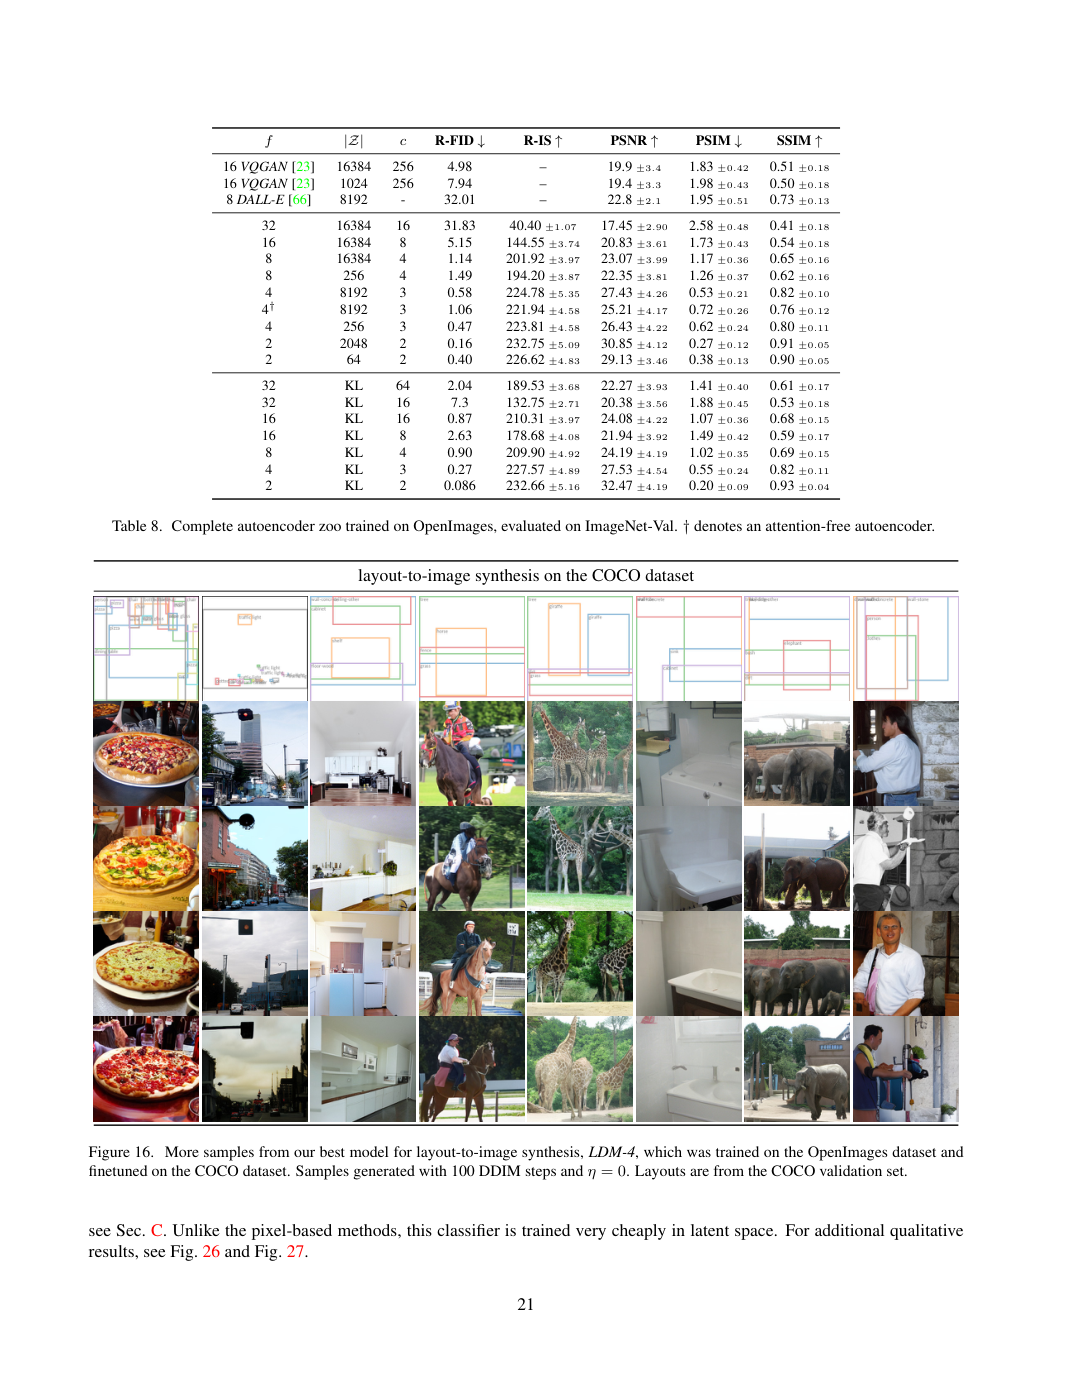

In [3]:
page = doc[PAGE_INDEX]

MODEL_DPI = 300
model_zoom = MODEL_DPI / 72
pixmap = page.get_pixmap(matrix=fitz.Matrix(model_zoom, model_zoom), alpha=False)
page_png_bytes = pixmap.tobytes("png")
if not page_png_bytes:
    raise RuntimeError("頁面圖片渲染失敗。")

PREVIEW_MAX_HEIGHT = 1400
preview_zoom = PREVIEW_MAX_HEIGHT / page.rect.height
preview_pixmap = page.get_pixmap(
    matrix=fitz.Matrix(preview_zoom, preview_zoom), alpha=False
)
preview_png_bytes = preview_pixmap.tobytes("png")

print(
    f"模型輸入：{pixmap.width} × {pixmap.height} px，"
    f"約 {len(page_png_bytes) / 1024:.0f} KB"
)
print(f"畫面預覽：{preview_pixmap.width} × {preview_pixmap.height} px")
display(Image(data=preview_png_bytes, width=550))


## Step 3 — 用 `pypdf` 擷取文字層

`pypdf` 的 `extract_text()` 主要讀取 PDF 文字層。這一步核對指定表格列、圖說結尾、頁碼與幾個物件詞；它本來就不是圖片描述模型。


In [4]:
pypdf_text = reader.pages[PAGE_INDEX].extract_text() or ""
if not pypdf_text.strip():
    raise RuntimeError("pypdf 沒有擷取到文字；這一頁可能沒有可用的文字層。")

print("=== pypdf 完整原始輸出 ===")
print(pypdf_text)
print("=== pypdf 原始輸出結束 ===")


=== pypdf 完整原始輸出 ===
f |Z| c R-FID ↓ R-IS ↑ PSNR ↑ PSIM ↓ SSIM ↑
16 VQGAN [23] 16384 256 4.98 – 19.9 ±3.4 1.83 ±0.42 0.51 ±0.18
16 VQGAN [23] 1024 256 7.94 – 19.4 ±3.3 1.98 ±0.43 0.50 ±0.18
8 DALL-E [66] 8192 - 32.01 – 22.8 ±2.1 1.95 ±0.51 0.73 ±0.13
32 16384 16 31.83 40.40 ±1.07 17.45 ±2.90 2.58 ±0.48 0.41 ±0.18
16 16384 8 5.15 144.55 ±3.74 20.83 ±3.61 1.73 ±0.43 0.54 ±0.18
8 16384 4 1.14 201.92 ±3.97 23.07 ±3.99 1.17 ±0.36 0.65 ±0.16
8 256 4 1.49 194.20 ±3.87 22.35 ±3.81 1.26 ±0.37 0.62 ±0.16
4 8192 3 0.58 224.78 ±5.35 27.43 ±4.26 0.53 ±0.21 0.82 ±0.10
4† 8192 3 1.06 221.94 ±4.58 25.21 ±4.17 0.72 ±0.26 0.76 ±0.12
4 256 3 0.47 223.81 ±4.58 26.43 ±4.22 0.62 ±0.24 0.80 ±0.11
2 2048 2 0.16 232.75 ±5.09 30.85 ±4.12 0.27 ±0.12 0.91 ±0.05
2 64 2 0.40 226.62 ±4.83 29.13 ±3.46 0.38 ±0.13 0.90 ±0.05
32 KL 64 2.04 189.53 ±3.68 22.27 ±3.93 1.41 ±0.40 0.61 ±0.17
32 KL 16 7.3 132.75 ±2.71 20.38 ±3.56 1.88 ±0.45 0.53 ±0.18
16 KL 16 0.87 210.31 ±3.97 24.08 ±4.22 1.07 ±0.36 0.68 ±0.15
16 KL 8 2.63 17

In [5]:
normalized_pypdf_text = " ".join(pypdf_text.split())
EXPECTED_TABLE_ROW = (
    "32 16384 16 31.83 40.40 ±1.07 17.45 ±2.90 2.58 ±0.48 0.41 ±0.18"
)
EXPECTED_CAPTION_END = "Layouts are from the COCO validation set."
EXPECTED_PAGE_NUMBER = str(PAGE_INDEX + 1)
SELECTED_OBJECT_TERMS = ("pizza", "giraffe", "elephant", "披薩", "長頸鹿", "大象")

pypdf_has_expected_row = EXPECTED_TABLE_ROW in normalized_pypdf_text
pypdf_has_caption_end = EXPECTED_CAPTION_END in pypdf_text
pypdf_page_number_count = sum(
    line.strip() == EXPECTED_PAGE_NUMBER for line in pypdf_text.splitlines()
)
pypdf_page_number_is_last_line = (
    pypdf_text.strip().splitlines()[-1].strip() == EXPECTED_PAGE_NUMBER
)
pypdf_mentions_selected_object_terms = any(
    term in pypdf_text.lower() for term in SELECTED_OBJECT_TERMS
)

print(f"擷取字元數：{len(pypdf_text)}")
print(f"Table 8 指定列一致：{pypdf_has_expected_row}")
print(f"圖說結尾一致：{pypdf_has_caption_end}")
print(
    "頁碼位於最後一行且只出現一次："
    f"{pypdf_page_number_is_last_line and pypdf_page_number_count == 1}"
)
print(f"特定物件詞抽查有命中：{pypdf_mentions_selected_object_terms}")


擷取字元數：1785
Table 8 指定列一致：True
圖說結尾一致：True
頁碼位於最後一行且只出現一次：True
特定物件詞抽查有命中：False


### 觀察時先看什麼？

- 原始輸出的表格欄位是否仍連在正確的資料列？
- 圖說、正文與頁碼的閱讀順序是否合理？
- 自動檢查只能確認指定字串或位置條件，不能取代人工通讀。

### 解釋限制

- `pypdf` 主要擷取文字層，沒有描述 Figure 16 的生成影像，是工具能力邊界，不應解釋成模型 OCR 失敗。
- 關鍵字檢查只顯示**特定詞**是否出現；詞沒有出現，不能代表完整的圖片理解。反過來，即使詞有出現，也可能只是來自圖說。


## Step 4 — 模擬其中一種視覺讀圖路徑

這一步把 Step 2 的**單頁 PNG** 送給 Groq 的 `qwen/qwen3.6-27b`，請它謄寫文字，並簡短描述非文字內容。

這只模擬其中一種視覺讀圖路徑，**不等同於真實 chatbot 的 PDF ingestion**。實際產品還可能加入 OCR、版面解析、分頁、切塊或其他前處理。

提示同時要求「逐字謄寫」與「描述非文字內容」，是混合任務。若模型沒有描述影像，不能直接斷言是 OCR 失敗，也不能只靠這次結果判定模型無法理解圖片。

`qwen/qwen3.6-27b` 是 Preview 模型；速率限制會依帳戶與方案而異。請參考 [Groq Rate Limits](https://console.groq.com/docs/rate-limits)，並以 Groq Console 中**自己的 Limits** 為準。這裡關閉深度推理並限制輸出長度，以降低超出限制的機會。


In [6]:
TRANSCRIBE_PROMPT = (
    "請把這張 PDF 頁面的內容逐字謄寫出來，照你看到的視覺閱讀順序輸出，"
    "不要摘要、不要修正看起來奇怪的地方、不要補充頁面上沒有的說明。"
    "如果有些內容不是連續段落文字（例如圖表、圖片），"
    "請在該處簡短描述你看到的視覺結構。"
)


def transcribe_page_with_groq(png_bytes: bytes) -> str:
    groq_api_key = os.environ.get("GROQ_API_KEY")
    if not groq_api_key:
        raise RuntimeError(
            "找不到 GROQ_API_KEY。請在專案根目錄的 .env 設定金鑰，"
            "再重新執行這一格。"
        )

    groq_client = Groq(api_key=groq_api_key)
    image_b64 = base64.standard_b64encode(png_bytes).decode("utf-8")
    try:
        response = groq_client.chat.completions.create(
            model="qwen/qwen3.6-27b",
            reasoning_effort="none",
            max_completion_tokens=2000,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": TRANSCRIBE_PROMPT},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/png;base64,{image_b64}"
                            },
                        },
                    ],
                }
            ],
        )
    except groq.RateLimitError:
        raise RuntimeError(
            "Groq 目前達到帳戶限制；請查看 Console 的 Limits，稍後再試。"
        ) from None
    except groq.AuthenticationError:
        raise RuntimeError("GROQ_API_KEY 無效，請確認 .env 中的設定。") from None
    except (groq.APIConnectionError, groq.APITimeoutError):
        raise RuntimeError("連不上 Groq，請確認網路連線後重試。") from None
    except groq.APIStatusError as error:
        raise RuntimeError(
            f"Groq API 回傳錯誤：{error.status_code} {error.message}"
        ) from None

    choices = getattr(response, "choices", None)
    if not choices:
        raise RuntimeError("Groq 回應缺少 choices，無法取得模型輸出。")

    choice = choices[0]
    message = getattr(choice, "message", None)
    content = getattr(message, "content", None) if message is not None else None
    if not isinstance(content, str) or not content.strip():
        raise RuntimeError("Groq 回應缺少可用的文字內容，請重新執行這一格。")
    if getattr(choice, "finish_reason", None) == "length":
        raise RuntimeError(
            "回應被 max_completion_tokens 截斷，內容不完整，不能用於這次比對。"
        )
    return content


qwen_text = transcribe_page_with_groq(page_png_bytes)
if not qwen_text.strip():
    raise RuntimeError("視覺模型結果是空字串，無法進行比對。")

print("=== 視覺模型完整原始輸出 ===")
print(qwen_text)
print("=== 視覺模型原始輸出結束 ===")


=== 視覺模型完整原始輸出 ===
以下是根据您提供的图片内容，逐字誊写的结果。遇到表格或无法辨认的文字部分，会进行简短描述。

### 顶部区域

```
|    R-FID↓        PSNR↑          PSIM↓          SSIM↑  
16 VQQAN [23]   16384   256    4.98           -    1.83 ± 0.42   0.51 ± 0.18
16 VQGA...[22]  1024    256    7.92           -    1.98 ± 0.43   0.50 ± 0.18
8 DALL-E [66]   8192    -     32.01          -    0.73 ± 0.18
```

### 中间左侧区域

这部分是三个并列的图片网格，每个网格由4行8列的小图组成，共3行6列的大图。这些小图展示了不同场景下的合成图像，如食物、街景等。

### 中间右侧区域

#### 表格
表格包含以下列：
- `f`
- `|Z|`
- `c`
- `R-FID↓`
- `PSNR↑`
- `PSIM↓`
- `SSIM↑`

表格的具体内容如下：

```
| f  | Z    | c   | R-FID↓ | PSNR↑       | PSIM↓       | SSIM↑       |
|----|------|-----|--------|-------------|-------------|-------------|
| 32 | 16384| 8   | 144.55 |             |             |             |
| 16 | 16384| 8   | 144.55 |             |             |             |
| 8  | 8192 | 4   | 224.78 |             |             |             |
| 8  | 256  | 4   | 194.20 |             |             |             |
| 4  | 8192 | 3   | 221.94 |   

In [7]:
normalized_qwen_text = " ".join(qwen_text.split())
qwen_has_table_left_part = (
    "32 16384 16 31.83 40.40" in normalized_qwen_text
)
qwen_has_table_right_part = (
    "± 1.07 17.45 ± 2.90 2.58 ± 0.48 0.41 ± 0.18"
    in normalized_qwen_text
)
qwen_has_extra_values = (
    "16.7 ± 3.1 5.03 ± 0.09 0.32 ± 0.01" in normalized_qwen_text
)
qwen_has_caption_end = EXPECTED_CAPTION_END in qwen_text
qwen_page_number_count = sum(
    line.strip() == EXPECTED_PAGE_NUMBER for line in qwen_text.splitlines()
)
qwen_page_number_is_last_line = (
    qwen_text.strip().splitlines()[-1].strip() == EXPECTED_PAGE_NUMBER
)
qwen_mentions_selected_object_terms = any(
    term in qwen_text.lower() for term in SELECTED_OBJECT_TERMS
)

boolean_label = lambda value: "是" if value else "否"
automatic_check_markdown = f"""### 本次自動檢查

| 可由程式直接檢查的項目 | 結果 |
| --- | --- |
| 回應字元數 | {len(qwen_text)} |
| Table 8 左側指定片段存在 | {boolean_label(qwen_has_table_left_part)} |
| Table 8 右側指定片段存在 | {boolean_label(qwen_has_table_right_part)} |
| 指定的額外數值片段存在 | {boolean_label(qwen_has_extra_values)} |
| 圖說結尾存在 | {boolean_label(qwen_has_caption_end)} |
| 頁碼位於最後一行且只出現一次 | {boolean_label(qwen_page_number_is_last_line and qwen_page_number_count == 1)} |
| Figure 16 是否被描述 | 需人工通讀全文判定；關鍵字抽查只供線索（特定詞命中：{boolean_label(qwen_mentions_selected_object_terms)}） |

> `True／是` 只代表指定字串或條件成立，不自動證明欄位對齊、整列正確或圖片理解完整。
"""
display(Markdown(automatic_check_markdown))


### 本次自動檢查

| 可由程式直接檢查的項目 | 結果 |
| --- | --- |
| 回應字元數 | 2648 |
| Table 8 左側指定片段存在 | 否 |
| Table 8 右側指定片段存在 | 否 |
| 指定的額外數值片段存在 | 否 |
| 圖說結尾存在 | 是 |
| 頁碼位於最後一行且只出現一次 | 否 |
| Figure 16 是否被描述 | 需人工通讀全文判定；關鍵字抽查只供線索（特定詞命中：否） |

> `True／是` 只代表指定字串或條件成立，不自動證明欄位對齊、整列正確或圖片理解完整。


## Step 5 — 解讀規則與限制

Step 4 的「本次自動檢查」會隨每次 API 回應動態更新。解讀時請遵守以下界線：

### 直接觀察

- 左右片段各自存在，只能證明兩段指定字串出現在輸出中；不能自動推論它們屬於同一列、欄位正確對齊或整張表正確。
- 指定的額外數值片段存在，只代表輸出含有該字串；仍要回到原頁人工核對，才能判斷它是否來自頁面。
- 圖說與頁碼檢查只涵蓋指定文字和位置條件，不代表其他內容也正確。
- Figure 16 是否被描述，必須人工通讀完整輸出；關鍵字有無命中都只是一條線索。

### 解釋與限制

- `pypdf` 主要擷取文字層，沒有描述生成影像是工具能力邊界，不應解釋成模型 OCR 失敗。
- 混合提示同時要求逐字謄寫與圖片描述，因此遺漏影像描述時，無法只靠這個實驗區分 OCR、視覺理解、指令遵循或輸出長度的影響。
- 人工錨點只涵蓋一列數值、版面結構、圖說與頁碼；它是有限的評估錨點，不是完整 ground truth。
- 這是探索性、單頁、單模型、單次輸出的示範，不能推論 `pypdf`、Groq、Qwen、視覺模型或 chatbot 的整體準確率。

每次重新執行後，先看動態檢查，再人工檢視完整輸出，最後才記錄「觀察」與「解釋」。重要數值與結論仍應回到可驗證的原頁核對。


## Next Steps

如果要把這個示範變成更可靠的評測，可以：

1. 把「逐字謄寫」與「圖片描述」拆成兩個提示，避免混合任務造成歸因困難。
2. 預先定義更多人工核對項目，並由第二位標註者複查，降低人工錨點錯誤。
3. 增加不同頁型（純文字、表格、掃描頁、純圖片）、模型與重複次數，再分開統計文字、表格與圖像結果。
4. 保留失敗、無輸出與不一致案例；不要只挑成功範例形成結論。

### 延伸資料

- [pypdf 文件](https://pypdf.readthedocs.io/)
- [PyMuPDF 文件](https://pymupdf.readthedocs.io/)
- [Groq Vision 文件](https://console.groq.com/docs/vision)
- [Groq Reasoning 文件](https://console.groq.com/docs/reasoning)
- [Groq Rate Limits](https://console.groq.com/docs/rate-limits)
